# QA/QC — `FE_VI_observed_local15_2018`

This notebook QA/QCs the completed 2018 feature-engineered VI export **locally**, so no additional Earth Engine compute is required.

The product expected here is the original independent-event workflow with five VIs:

- NDVI
- OSAVI
- CVI
- NDRE
- NIRv

and six features per VI:

- `VI0`
- `DOY0`
- `max`
- `DOYmax`
- `deltaRise`
- `sRise`

for **30 bands total**.

The QA/QC checks four things:

1. **Raster structure** — shard consistency, CRS, resolution, band count, nodata, band descriptions.
2. **Numerical behavior** — finite values, valid-pixel fractions, quantiles and extreme values.
3. **Internal identities** — `deltaRise = max - VI0` and `sRise = deltaRise / (DOYmax - DOY0)`.
4. **Phenological behavior** — DOY ordering, timing distributions, and agreement/disagreement among the five independently detected VI events.

The default workflow uses a spatially distributed downsample from every shard rather than reading every 10 m pixel into memory. Set `RUN_FULL_SCAN = True` only if an exact pixel census is needed.

In [1]:
# Optional one-time install
# %pip install -q numpy pandas matplotlib rasterio google-cloud-storage

from pathlib import Path
import math
import shutil
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.enums import Resampling

warnings.filterwarnings("ignore", category=RuntimeWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)


## 1. Configuration

In [2]:
# ---------------------------------------------------------------------------
# GCS source produced by the 2018 Earth Engine export
# ---------------------------------------------------------------------------

GCS_BUCKET = "bop-nca-data-space-s2-c1-staging"
GCS_PREFIX = "FE_VI_observed_local15/2018/FE_VI_observed_local15_2018"

# Change this if you want the files somewhere else locally.
LOCAL_DIR = Path("FE_VI_observed_local15_2018")
LOCAL_DIR.mkdir(parents=True, exist_ok=True)

QA_DIR = LOCAL_DIR / "QAQC"
QA_DIR.mkdir(parents=True, exist_ok=True)

# Approximate number of spatially distributed sample pixels to retain per shard.
# 20,000/shard is enough to characterize distributions without loading the
# entire raster into RAM.
SAMPLES_PER_SHARD = 20_000

# False = sampled QA/QC only.
# True  = additionally perform an exact blockwise scan of every pixel.
RUN_FULL_SCAN = False

VIS = ["NDVI", "OSAVI", "CVI", "NDRE", "NIRv"]

EXPECTED_SUFFIXES = [
    "VI0",
    "DOY0",
    "max",
    "DOYmax",
    "deltaRise",
    "sRise",
]

EXPECTED_BAND_COUNT = len(VIS) * len(EXPECTED_SUFFIXES)
EXPECTED_BAND_COUNT


30

## 2. Discover/download the GeoTIFF shards

If the TIFFs are already in `LOCAL_DIR`, the download is skipped. Otherwise this uses the Google Cloud Storage Python client and your existing Google credentials.

In [3]:
def local_tifs():
    return sorted(
        p for p in LOCAL_DIR.glob("*.tif")
        if p.is_file()
    )


tifs = local_tifs()

if not tifs:
    from google.cloud import storage

    client = storage.Client()
    bucket = client.bucket(GCS_BUCKET)

    blobs = [
        b for b in client.list_blobs(
            GCS_BUCKET,
            prefix=GCS_PREFIX
        )
        if b.name.lower().endswith(".tif")
    ]

    if not blobs:
        raise FileNotFoundError(
            f"No GeoTIFFs found under gs://{GCS_BUCKET}/{GCS_PREFIX}"
        )

    print(f"Downloading {len(blobs)} shard(s)...")

    for blob in blobs:
        out = LOCAL_DIR / Path(blob.name).name

        if not out.exists():
            blob.download_to_filename(out)

    tifs = local_tifs()

print(f"Local shards: {len(tifs)}")
for p in tifs:
    print(" ", p.name)


Local shards: 4
  FE_VI_observed_local15_20180000000000-0000000000.tif
  FE_VI_observed_local15_20180000000000-0000006144.tif
  FE_VI_observed_local15_20180000006144-0000000000.tif
  FE_VI_observed_local15_20180000006144-0000006144.tif


## 3. Raster inventory and schema consistency

In [4]:
def describe_raster(path):
    with rasterio.open(path) as src:
        return {
            "file": path.name,
            "width": src.width,
            "height": src.height,
            "count": src.count,
            "dtype": ",".join(sorted(set(src.dtypes))),
            "crs": str(src.crs),
            "res_x": abs(src.transform.a),
            "res_y": abs(src.transform.e),
            "nodata": src.nodata,
            "left": src.bounds.left,
            "bottom": src.bounds.bottom,
            "right": src.bounds.right,
            "top": src.bounds.top,
            "descriptions": list(src.descriptions),
        }


inventory_raw = [describe_raster(p) for p in tifs]

inventory = pd.DataFrame([
    {k: v for k, v in row.items() if k != "descriptions"}
    for row in inventory_raw
])

display(inventory)

inventory.to_csv(QA_DIR / "raster_inventory.csv", index=False)

# Structural assertions
assert inventory["count"].nunique() == 1, "Shard band counts differ."
assert inventory["crs"].nunique() == 1, "Shard CRS values differ."
assert inventory["dtype"].nunique() == 1, "Shard data types differ."
assert inventory["nodata"].nunique() == 1, "Shard nodata values differ."

band_count = int(inventory.iloc[0]["count"])
print("\nBand count:", band_count)
print("Expected:", EXPECTED_BAND_COUNT)

if band_count != EXPECTED_BAND_COUNT:
    print(
        "WARNING: band count differs from the expected 30-band "
        "independent-VI event product."
    )

print("\nCRS:", inventory.iloc[0]["crs"])
print(
    "Resolution:",
    inventory.iloc[0]["res_x"],
    "x",
    inventory.iloc[0]["res_y"],
)
print("NoData:", inventory.iloc[0]["nodata"])


,file,width,height,count,dtype,crs,res_x,res_y,nodata,left,bottom,right,top
0,FE_VI_observed_local15_20180000000000-00000000...,6144,6144,30,float32,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",10.0,10.0,-32768.0,527740.0,4753970.0,589180.0,4815410.0
1,FE_VI_observed_local15_20180000000000-00000061...,4291,6144,30,float32,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",10.0,10.0,-32768.0,589180.0,4753970.0,632090.0,4815410.0
2,FE_VI_observed_local15_20180000006144-00000000...,6144,1713,30,float32,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",10.0,10.0,-32768.0,527740.0,4736840.0,589180.0,4753970.0
3,FE_VI_observed_local15_20180000006144-00000061...,4291,1713,30,float32,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",10.0,10.0,-32768.0,589180.0,4736840.0,632090.0,4753970.0



Band count: 30
Expected: 30

CRS: PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North American Datum 1983",SPHEROID["GRS 1980",6378137,298.257222101004]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Resolution: 10.0 x 10.0
NoData: -32768.0


## 4. Recover and validate band names

In [5]:
first_descriptions = inventory_raw[0]["descriptions"]

if all(x is not None for x in first_descriptions):
    band_names = list(first_descriptions)
else:
    band_names = [f"band_{i}" for i in range(1, band_count + 1)]
    print(
        "WARNING: GeoTIFF band descriptions are missing. "
        "Logical feature checks will be limited until names are supplied."
    )

print("Bands:")
for i, name in enumerate(band_names, start=1):
    print(f"{i:02d}: {name}")

# Confirm every shard has the same band descriptions.
for row in inventory_raw[1:]:
    if list(row["descriptions"]) != list(first_descriptions):
        raise AssertionError(
            f"Band descriptions differ in shard {row['file']}"
        )


def find_band(vi, suffix):
    """Resolve a band robustly against a few plausible naming variants."""
    targets = [
        f"{vi}_{suffix}",
        f"{vi}_{suffix.lower()}",
        f"{vi}_{suffix.upper()}",
    ]

    low_map = {str(x).lower(): x for x in band_names}

    for target in targets:
        if target.lower() in low_map:
            return low_map[target.lower()]

    # Looser suffix matching if EE preserved slightly different capitalization.
    candidates = [
        x for x in band_names
        if str(x).lower().startswith(vi.lower() + "_")
        and str(x).lower().endswith(suffix.lower())
    ]

    return candidates[0] if len(candidates) == 1 else None


resolved = []
for vi in VIS:
    row = {"VI": vi}
    for suffix in EXPECTED_SUFFIXES:
        row[suffix] = find_band(vi, suffix)
    resolved.append(row)

resolved = pd.DataFrame(resolved)
display(resolved)
resolved.to_csv(QA_DIR / "resolved_band_names.csv", index=False)


Bands:
01: NDVI_VI0
02: NDVI_doy0
03: NDVI_max
04: NDVI_doyMax
05: NDVI_deltaRise
06: NDVI_sRise
07: OSAVI_VI0
08: OSAVI_doy0
09: OSAVI_max
10: OSAVI_doyMax
11: OSAVI_deltaRise
12: OSAVI_sRise
13: CVI_VI0
14: CVI_doy0
15: CVI_max
16: CVI_doyMax
17: CVI_deltaRise
18: CVI_sRise
19: NDRE_VI0
20: NDRE_doy0
21: NDRE_max
22: NDRE_doyMax
23: NDRE_deltaRise
24: NDRE_sRise
25: NIRv_VI0
26: NIRv_doy0
27: NIRv_max
28: NIRv_doyMax
29: NIRv_deltaRise
30: NIRv_sRise


,VI,VI0,DOY0,max,DOYmax,deltaRise,sRise
0,NDVI,NDVI_VI0,NDVI_doy0,NDVI_max,NDVI_doyMax,NDVI_deltaRise,NDVI_sRise
1,OSAVI,OSAVI_VI0,OSAVI_doy0,OSAVI_max,OSAVI_doyMax,OSAVI_deltaRise,OSAVI_sRise
2,CVI,CVI_VI0,CVI_doy0,CVI_max,CVI_doyMax,CVI_deltaRise,CVI_sRise
3,NDRE,NDRE_VI0,NDRE_doy0,NDRE_max,NDRE_doyMax,NDRE_deltaRise,NDRE_sRise
4,NIRv,NIRv_VI0,NIRv_doy0,NIRv_max,NIRv_doyMax,NIRv_deltaRise,NIRv_sRise


## 5. Build a spatially distributed sample from every shard

This does **not** randomly pick contiguous windows. Each shard is resampled to a coarse grid, retaining coverage across its full spatial extent. NoData values are converted to `NaN`.

In [6]:
def sample_shard(path, target_n=SAMPLES_PER_SHARD):
    with rasterio.open(path) as src:
        # Preserve approximate aspect ratio while targeting target_n pixels.
        aspect = src.width / src.height
        out_h = max(1, int(math.sqrt(target_n / aspect)))
        out_w = max(1, int(out_h * aspect))

        arr = src.read(
            out_shape=(src.count, out_h, out_w),
            resampling=Resampling.nearest,
        ).astype("float64")

        nodata = src.nodata

        if nodata is not None:
            arr[arr == nodata] = np.nan

        arr[~np.isfinite(arr)] = np.nan

        flat = arr.reshape(src.count, -1).T

        df = pd.DataFrame(flat, columns=band_names)
        df["source_shard"] = path.name
        return df


sample_parts = []

for path in tifs:
    part = sample_shard(path)
    sample_parts.append(part)
    print(path.name, "->", f"{len(part):,}", "sample locations")

sample = pd.concat(sample_parts, ignore_index=True)

print("\nTotal sampled locations:", f"{len(sample):,}")
print("Columns:", len(sample.columns) - 1)


FE_VI_observed_local15_20180000000000-0000000000.tif -> 19,881 sample locations
FE_VI_observed_local15_20180000000000-0000006144.tif -> 19,942 sample locations
FE_VI_observed_local15_20180000006144-0000000000.tif -> 19,610 sample locations
FE_VI_observed_local15_20180000006144-0000006144.tif -> 19,758 sample locations

Total sampled locations: 79,191
Columns: 30


## 6. Band-level numerical summary

In [7]:
summary_rows = []
n_total = len(sample)

for band in band_names:
    x = pd.to_numeric(sample[band], errors="coerce")
    valid = x.dropna()

    if len(valid) == 0:
        stats = {
            "band": band,
            "n_sample": n_total,
            "n_valid": 0,
            "valid_fraction": 0.0,
            "min": np.nan,
            "p01": np.nan,
            "p05": np.nan,
            "p50": np.nan,
            "mean": np.nan,
            "p95": np.nan,
            "p99": np.nan,
            "max": np.nan,
            "std": np.nan,
        }
    else:
        q = valid.quantile([0.01, 0.05, 0.50, 0.95, 0.99])

        stats = {
            "band": band,
            "n_sample": n_total,
            "n_valid": len(valid),
            "valid_fraction": len(valid) / n_total,
            "min": valid.min(),
            "p01": q.loc[0.01],
            "p05": q.loc[0.05],
            "p50": q.loc[0.50],
            "mean": valid.mean(),
            "p95": q.loc[0.95],
            "p99": q.loc[0.99],
            "max": valid.max(),
            "std": valid.std(),
        }

    summary_rows.append(stats)

band_summary = pd.DataFrame(summary_rows)

display(band_summary)
band_summary.to_csv(QA_DIR / "band_summary_sampled.csv", index=False)


,band,n_sample,n_valid,valid_fraction,min,p01,p05,p50,mean,p95,p99,max,std
0,NDVI_VI0,79191,35199,0.444482,-0.112013,7.294777e-02,0.108362,0.239513,0.248425,0.397500,0.620485,0.937984,0.100936
1,NDVI_doy0,79191,35199,0.444482,2.000000,2.000000e+00,2.000000,37.000000,46.489531,134.000000,187.000000,312.000000,40.400413
2,NDVI_max,79191,36328,0.458739,0.003164,1.414521e-01,0.215504,0.411763,0.457204,0.905598,0.939753,1.000000,0.197306
3,NDVI_doyMax,79191,36328,0.458739,2.000000,1.400000e+01,49.000000,114.000000,120.649692,222.000000,284.000000,362.000000,49.482950
4,NDVI_deltaRise,79191,35199,0.444482,-0.466770,-7.016212e-03,0.014549,0.147369,0.213236,0.733542,0.806803,0.889586,0.205282
5,NDVI_sRise,79191,35199,0.444482,-0.011547,-1.713292e-04,0.000369,0.002071,0.002837,0.009175,0.014216,0.115846,0.002954
6,OSAVI_VI0,79191,35881,0.453094,-0.075822,6.224934e-02,0.090906,0.181780,0.190901,0.308427,0.468167,0.858378,0.078307
7,OSAVI_doy0,79191,35881,0.453094,2.000000,2.000000e+00,2.000000,37.000000,41.966054,129.000000,177.000000,332.000000,38.654385
8,OSAVI_max,79191,36328,0.458739,0.002744,1.192109e-01,0.175511,0.324459,0.377529,0.820879,0.875520,0.922251,0.186088
9,OSAVI_doyMax,79191,36328,0.458739,2.000000,3.700000e+01,64.000000,114.000000,123.003441,222.000000,279.000000,362.000000,45.715950


## 7. Phenological and algebraic consistency checks

For each VI, the expected identities are

\[
\Delta VI = VI_{max} - VI_0
\]

and

\[
S_{rise} = \frac{\Delta VI}{DOY_{max} - DOY_0}.
\]

The notebook also checks whether `DOY0 < DOYmax` and whether event dates remain inside the 2018 calendar year.

A small fraction of negative stabilized `deltaRise` values is not automatically an implementation failure: the event **timing** was selected from raw extrema while the reported magnitudes were stabilized with local medians. A large fraction would be a warning that this distinction matters.

In [8]:
def close_fraction(a, b, atol=1e-5, rtol=1e-4):
    ok = (
        np.isfinite(a)
        & np.isfinite(b)
    )

    if ok.sum() == 0:
        return np.nan

    close = np.isclose(
        a[ok],
        b[ok],
        atol=atol,
        rtol=rtol,
    )

    return close.mean()


check_rows = []

for _, mapping in resolved.iterrows():
    vi = mapping["VI"]

    required = {
        k: mapping[k]
        for k in EXPECTED_SUFFIXES
    }

    if any(v is None for v in required.values()):
        check_rows.append({
            "VI": vi,
            "status": "band names unresolved",
        })
        continue

    vi0 = sample[required["VI0"]].to_numpy(float)
    doy0 = sample[required["DOY0"]].to_numpy(float)
    vmax = sample[required["max"]].to_numpy(float)
    doymax = sample[required["DOYmax"]].to_numpy(float)
    delta = sample[required["deltaRise"]].to_numpy(float)
    slope = sample[required["sRise"]].to_numpy(float)

    common = (
        np.isfinite(vi0)
        & np.isfinite(doy0)
        & np.isfinite(vmax)
        & np.isfinite(doymax)
        & np.isfinite(delta)
        & np.isfinite(slope)
    )

    dt = doymax - doy0
    expected_delta = vmax - vi0

    with np.errstate(divide="ignore", invalid="ignore"):
        expected_slope = expected_delta / dt

    n = int(common.sum())

    if n == 0:
        check_rows.append({
            "VI": vi,
            "status": "no complete sampled records",
        })
        continue

    check_rows.append({
        "VI": vi,
        "status": "ok",
        "n_complete": n,
        "pct_DOY0_in_1_365": 100 * np.mean(
            (doy0[common] >= 1) & (doy0[common] <= 365)
        ),
        "pct_DOYmax_in_1_365": 100 * np.mean(
            (doymax[common] >= 1) & (doymax[common] <= 365)
        ),
        "pct_DOY0_lt_DOYmax": 100 * np.mean(
            doy0[common] < doymax[common]
        ),
        "pct_deltaRise_nonnegative": 100 * np.mean(
            delta[common] >= 0
        ),
        "pct_delta_identity_match": 100 * close_fraction(
            delta[common],
            expected_delta[common],
        ),
        "pct_slope_identity_match": 100 * close_fraction(
            slope[common],
            expected_slope[common],
        ),
        "median_deltaDOY": np.nanmedian(dt[common]),
        "p05_deltaDOY": np.nanpercentile(dt[common], 5),
        "p95_deltaDOY": np.nanpercentile(dt[common], 95),
    })


logical_checks = pd.DataFrame(check_rows)
display(logical_checks)

logical_checks.to_csv(
    QA_DIR / "logical_checks_sampled.csv",
    index=False
)


,VI,status,n_complete,pct_DOY0_in_1_365,pct_DOYmax_in_1_365,pct_DOY0_lt_DOYmax,pct_deltaRise_nonnegative,pct_delta_identity_match,pct_slope_identity_match,median_deltaDOY,p05_deltaDOY,p95_deltaDOY
0,NDVI,ok,35199,100.0,100.0,100.0,98.497116,100.0,100.0,77.0,23.0,138.00
1,OSAVI,ok,35881,100.0,100.0,100.0,98.996683,100.0,100.0,85.0,28.0,145.00
2,CVI,ok,32186,100.0,100.0,100.0,95.591251,100.0,100.0,85.0,12.0,225.00
3,NDRE,ok,33945,100.0,100.0,100.0,93.041685,100.0,100.0,93.0,12.0,253.00
4,NIRv,ok,36150,100.0,100.0,100.0,99.095436,100.0,100.0,92.0,35.0,172.55


## 8. DOY distributions for independently detected VI events

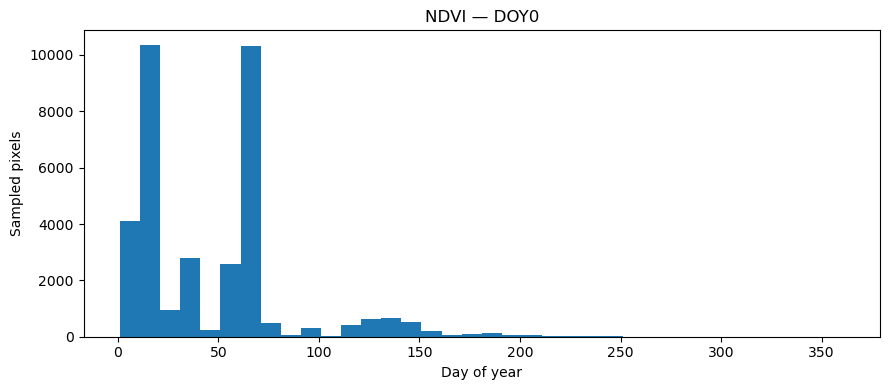

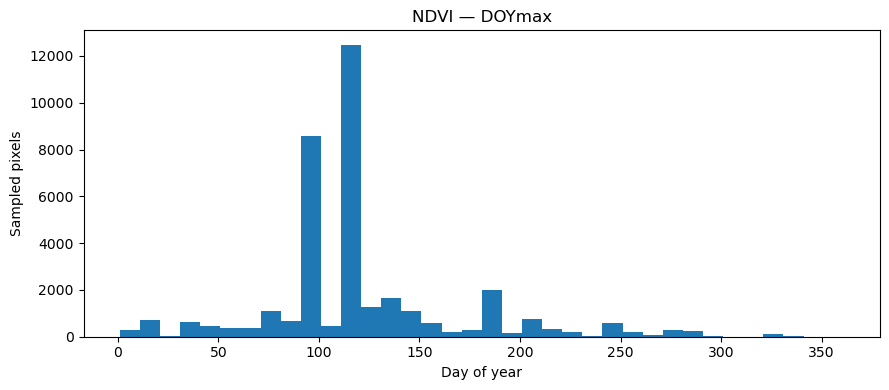

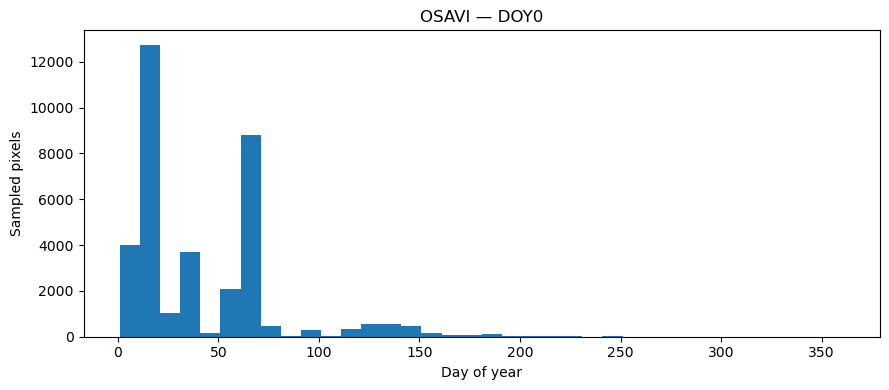

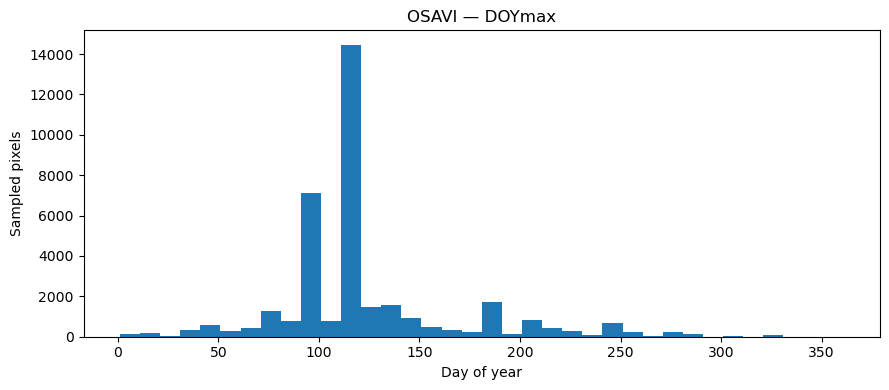

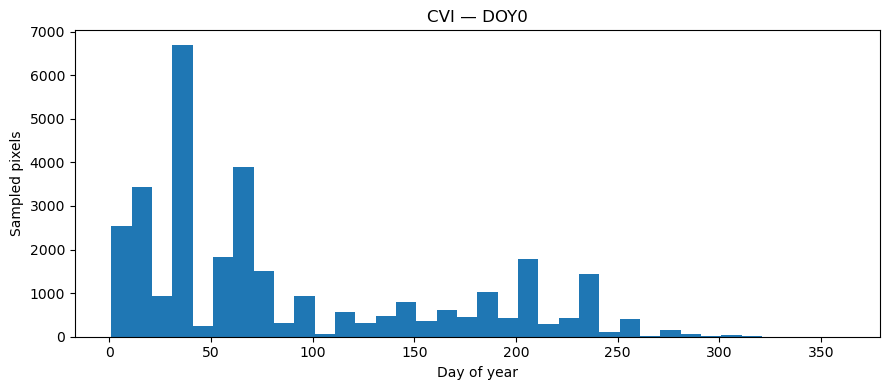

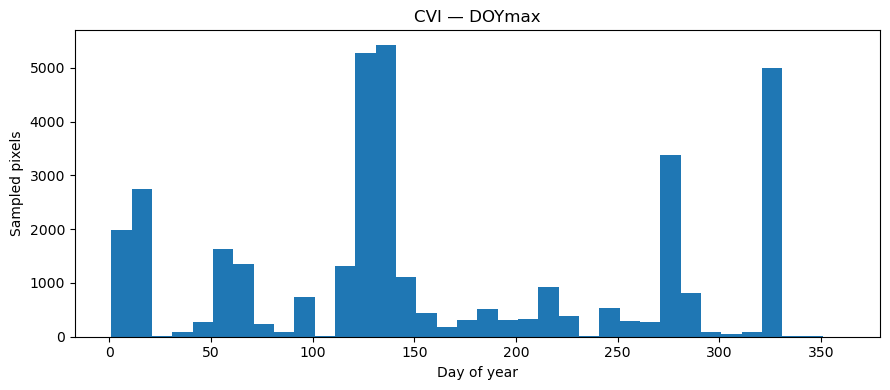

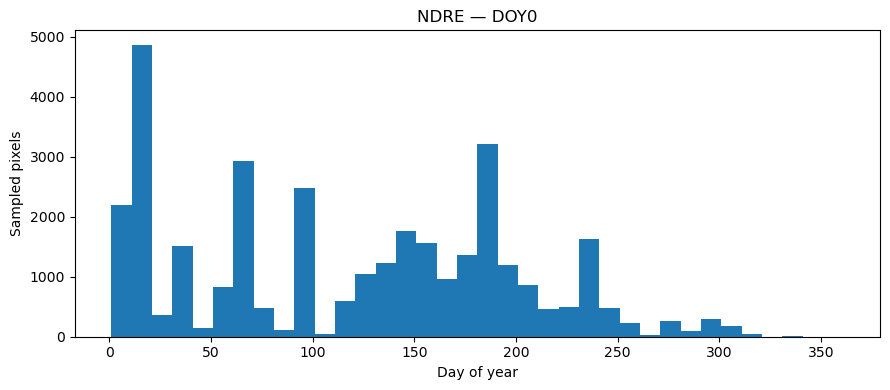

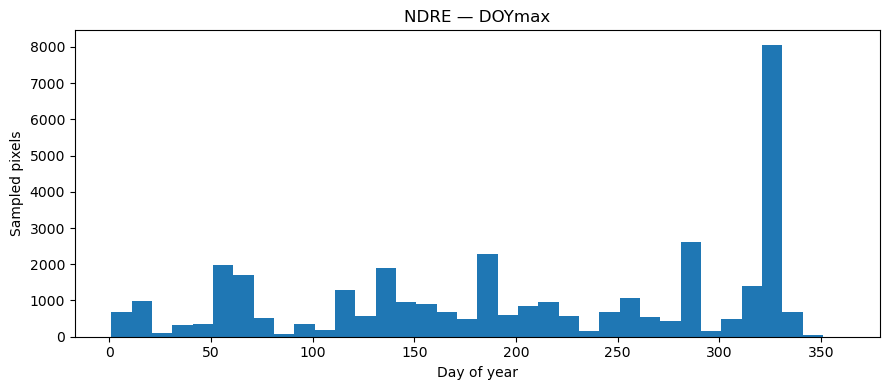

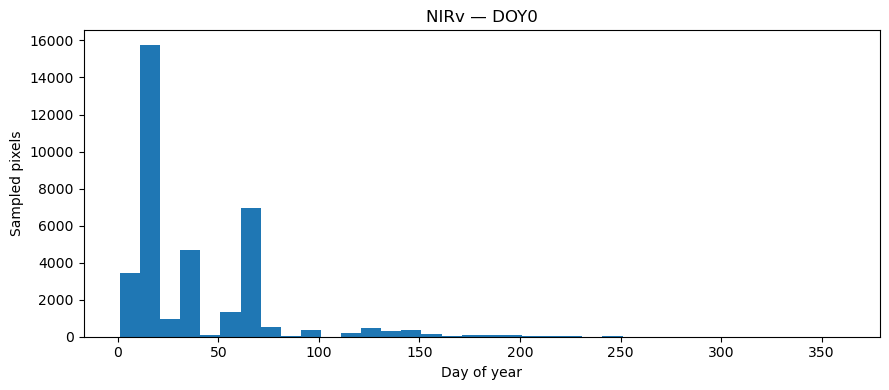

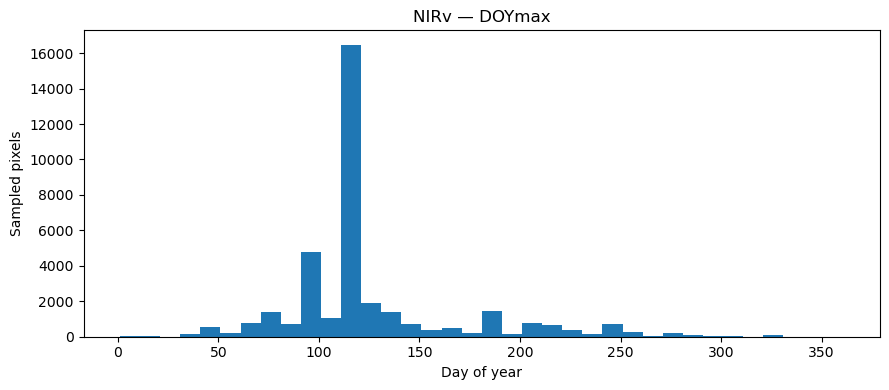

In [9]:
for vi in VIS:
    row = resolved.loc[resolved["VI"] == vi].iloc[0]

    for suffix in ["DOY0", "DOYmax"]:
        band = row[suffix]

        if band is None:
            continue

        x = sample[band].dropna()

        plt.figure(figsize=(9, 4))
        plt.hist(x, bins=np.arange(1, 367, 10))
        plt.xlabel("Day of year")
        plt.ylabel("Sampled pixels")
        plt.title(f"{vi} — {suffix}")
        plt.tight_layout()
        plt.show()


## 9. Compare event timing among VIs

Because this product estimated each VI's event timing independently, this is one of the most important diagnostics. We calculate pairwise median absolute DOY differences.

Large systematic disagreement is not automatically wrong—it may be evidence that the indices are responding to different spectral/ecological processes—but it tells us whether a single shared phenological clock would have been defensible.

In [10]:
def doy_matrix(suffix):
    cols = {}

    for vi in VIS:
        row = resolved.loc[resolved["VI"] == vi].iloc[0]
        band = row[suffix]

        if band is not None:
            cols[vi] = sample[band]

    return pd.DataFrame(cols)


def median_abs_difference_matrix(df):
    names = list(df.columns)
    out = pd.DataFrame(
        np.nan,
        index=names,
        columns=names,
    )

    for a in names:
        for b in names:
            valid = df[[a, b]].dropna()

            if len(valid):
                out.loc[a, b] = np.median(
                    np.abs(
                        valid[a].to_numpy()
                        - valid[b].to_numpy()
                    )
                )

    return out


doy0_df = doy_matrix("DOY0")
doymax_df = doy_matrix("DOYmax")

doy0_mad = median_abs_difference_matrix(doy0_df)
doymax_mad = median_abs_difference_matrix(doymax_df)

print("Median absolute difference in DOY0")
display(doy0_mad)

print("Median absolute difference in DOYmax")
display(doymax_mad)

doy0_mad.to_csv(QA_DIR / "DOY0_pairwise_median_abs_difference.csv")
doymax_mad.to_csv(QA_DIR / "DOYmax_pairwise_median_abs_difference.csv")


Median absolute difference in DOY0


,NDVI,OSAVI,CVI,NDRE,NIRv
NDVI,0.0,0.0,23.0,60.0,0.0
OSAVI,0.0,0.0,23.0,65.0,0.0
CVI,23.0,23.0,0.0,60.0,23.0
NDRE,60.0,65.0,60.0,0.0,75.0
NIRv,0.0,0.0,23.0,75.0,0.0


Median absolute difference in DOYmax


,NDVI,OSAVI,CVI,NDRE,NIRv
NDVI,0.0,0.0,35.0,88.0,0.0
OSAVI,0.0,0.0,38.0,88.0,0.0
CVI,35.0,38.0,0.0,75.0,45.0
NDRE,88.0,88.0,75.0,0.0,88.0
NIRv,0.0,0.0,45.0,88.0,0.0


## 10. DOY correlation among VIs

In [11]:
print("Spearman correlation — DOY0")
doy0_corr = doy0_df.corr(method="spearman")
display(doy0_corr)

print("Spearman correlation — DOYmax")
doymax_corr = doymax_df.corr(method="spearman")
display(doymax_corr)

doy0_corr.to_csv(QA_DIR / "DOY0_spearman.csv")
doymax_corr.to_csv(QA_DIR / "DOYmax_spearman.csv")


Spearman correlation — DOY0


,NDVI,OSAVI,CVI,NDRE,NIRv
NDVI,1.000000,0.861050,0.475665,0.169801,0.697877
OSAVI,0.861050,1.000000,0.451784,0.175096,0.807288
CVI,0.475665,0.451784,1.000000,0.167858,0.402389
NDRE,0.169801,0.175096,0.167858,1.000000,0.176213
NIRv,0.697877,0.807288,0.402389,0.176213,1.000000


Spearman correlation — DOYmax


,NDVI,OSAVI,CVI,NDRE,NIRv
NDVI,1.000000,0.926037,0.404391,-0.022457,0.829006
OSAVI,0.926037,1.000000,0.397899,-0.016426,0.889460
CVI,0.404391,0.397899,1.000000,0.101569,0.381577
NDRE,-0.022457,-0.016426,0.101569,1.000000,-0.006671
NIRv,0.829006,0.889460,0.381577,-0.006671,1.000000


## 11. VI magnitude diagnostics

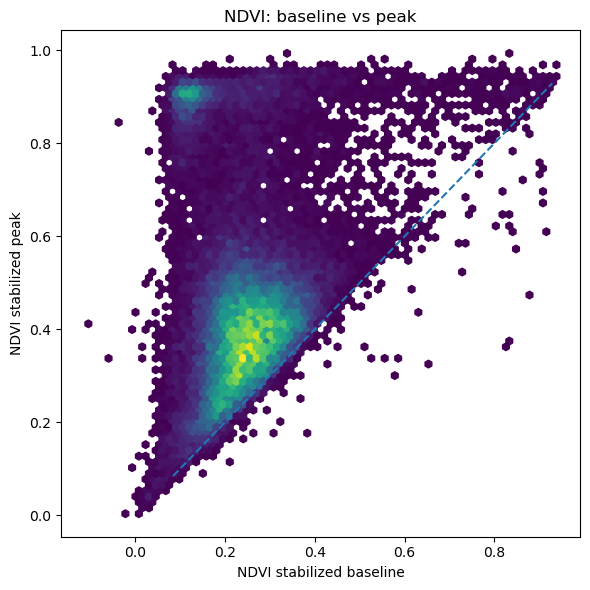

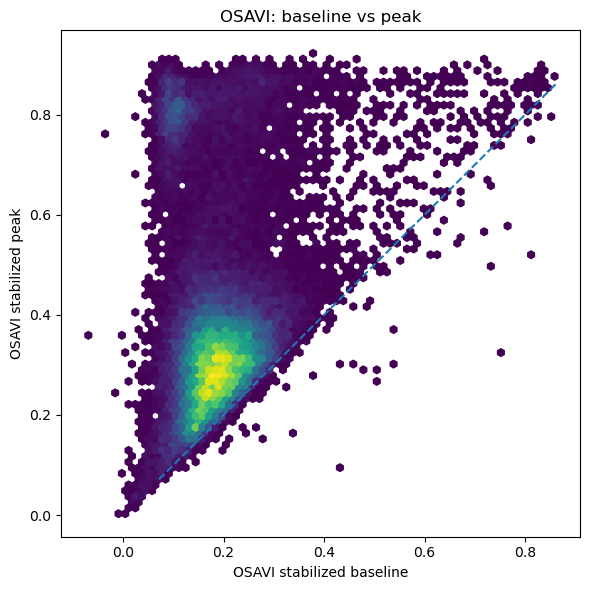

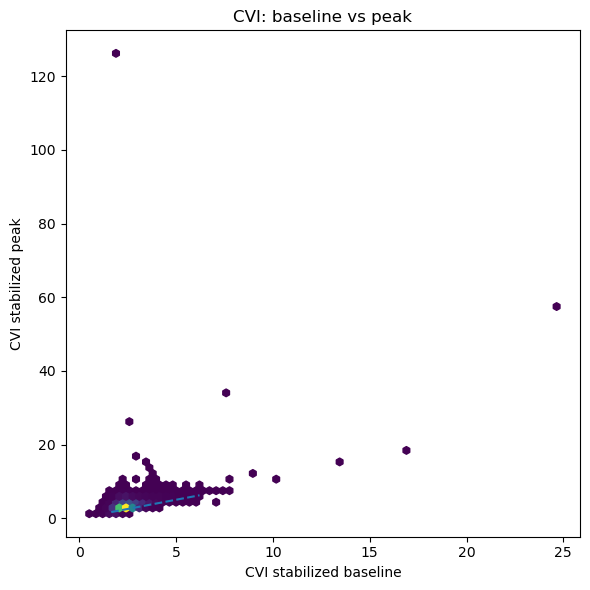

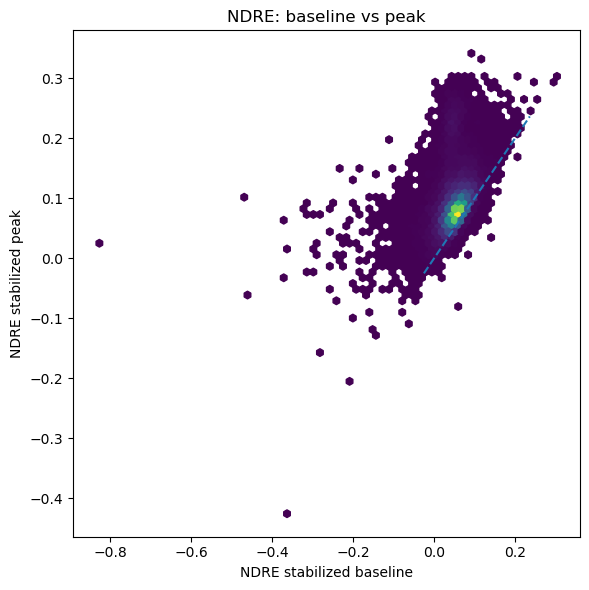

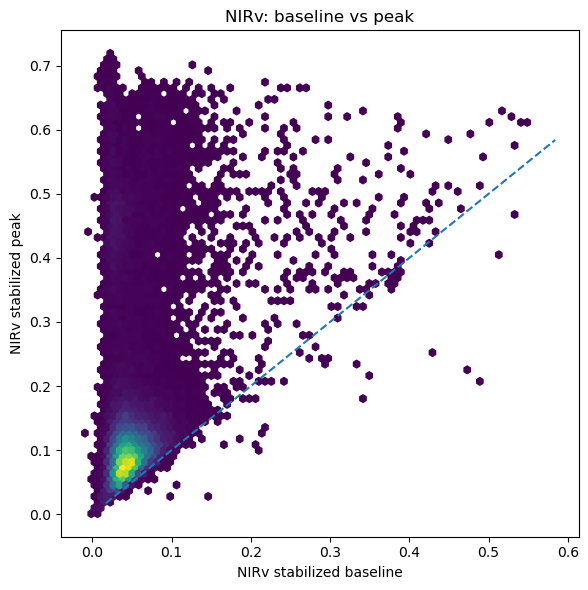

In [12]:
for vi in VIS:
    row = resolved.loc[resolved["VI"] == vi].iloc[0]

    b0 = row["VI0"]
    bp = row["max"]

    if b0 is None or bp is None:
        continue

    d = sample[[b0, bp]].dropna()

    if len(d) > 100_000:
        d = d.sample(
            100_000,
            random_state=42
        )

    plt.figure(figsize=(6, 6))
    plt.hexbin(
        d[b0],
        d[bp],
        gridsize=70,
        mincnt=1,
    )

    lo = np.nanpercentile(
        np.concatenate([d[b0], d[bp]]),
        1
    )
    hi = np.nanpercentile(
        np.concatenate([d[b0], d[bp]]),
        99
    )

    plt.plot(
        [lo, hi],
        [lo, hi],
        linestyle="--",
    )

    plt.xlabel(f"{vi} stabilized baseline")
    plt.ylabel(f"{vi} stabilized peak")
    plt.title(f"{vi}: baseline vs peak")
    plt.tight_layout()
    plt.show()


## 12. Optional mosaic VRT and spatial quicklooks

This uses the `gdalbuildvrt` command-line tool if available. It creates only a small VRT metadata file and does not duplicate the TIFF data.

In [13]:
VRT_PATH = LOCAL_DIR / "FE_VI_observed_local15_2018.vrt"

if shutil.which("gdalbuildvrt"):
    cmd = [
        "gdalbuildvrt",
        "-overwrite",
        str(VRT_PATH),
    ] + [str(p) for p in tifs]

    subprocess.run(
        cmd,
        check=True,
    )

    print("Created:", VRT_PATH)
else:
    print(
        "gdalbuildvrt is not available. "
        "Skipping the spatial mosaic quicklook."
    )


Created: FE_VI_observed_local15_2018\FE_VI_observed_local15_2018.vrt


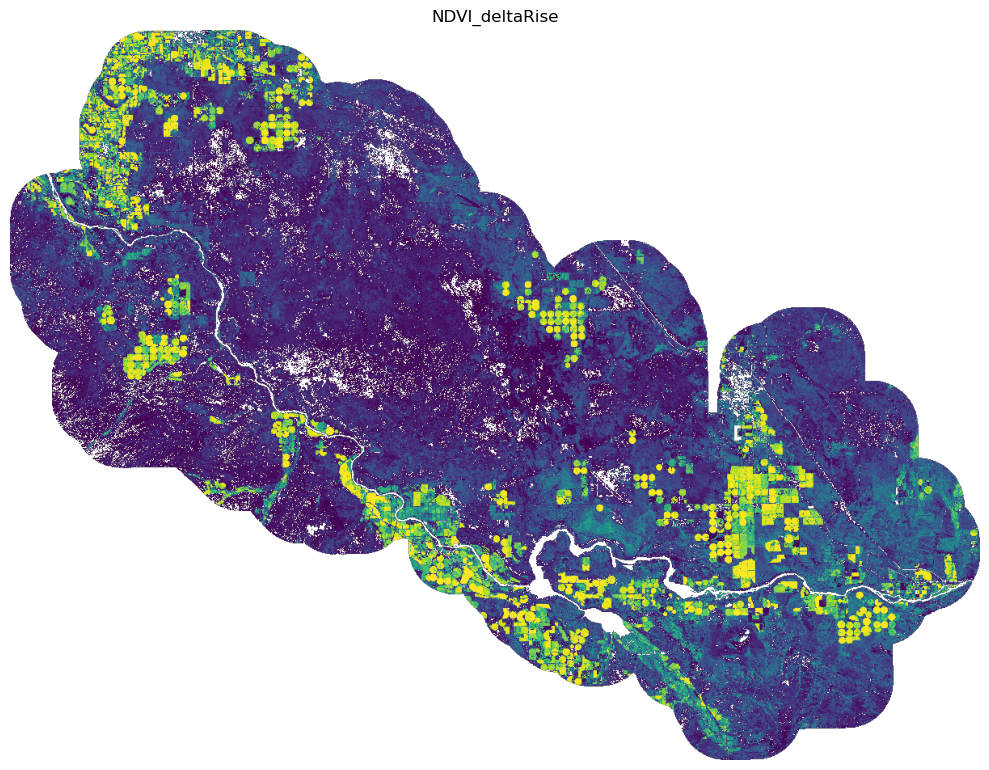

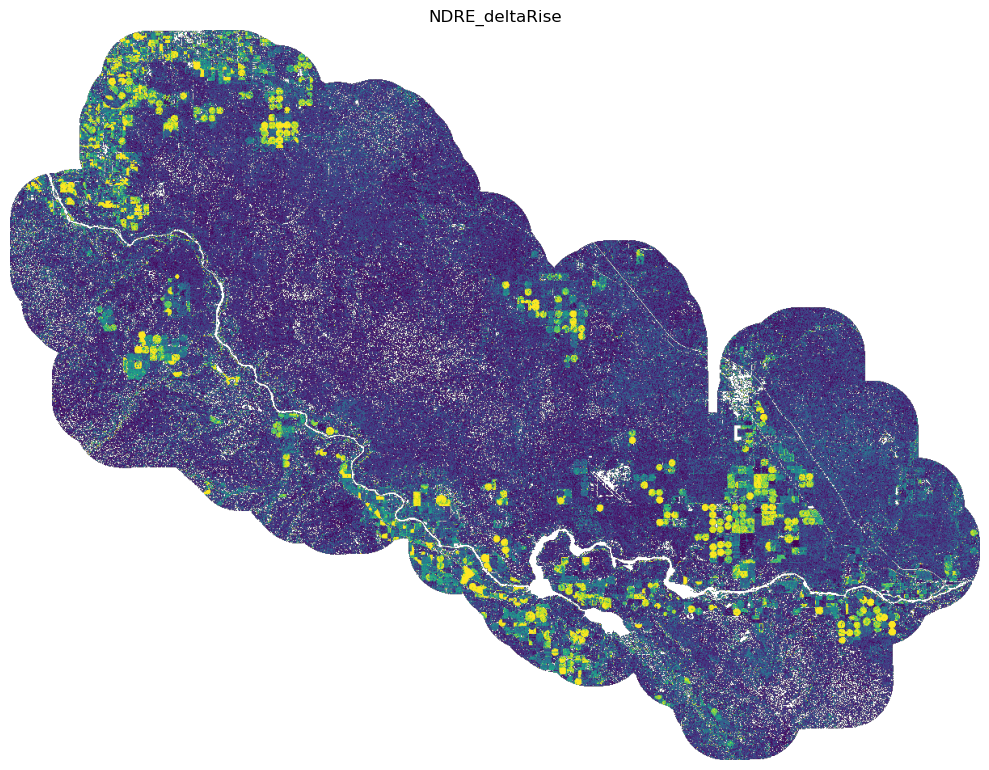

In [14]:
def quicklook_band(vrt_path, band_name, max_side=1200):
    if not Path(vrt_path).exists():
        print("VRT not available.")
        return

    if band_name not in band_names:
        print("Band not found:", band_name)
        return

    band_index = band_names.index(band_name) + 1

    with rasterio.open(vrt_path) as src:
        scale = max(src.width, src.height) / max_side

        if scale < 1:
            scale = 1

        out_w = max(1, int(src.width / scale))
        out_h = max(1, int(src.height / scale))

        arr = src.read(
            band_index,
            out_shape=(out_h, out_w),
            resampling=Resampling.nearest,
        ).astype("float64")

        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan

    valid = arr[np.isfinite(arr)]

    if valid.size == 0:
        print("No valid pixels:", band_name)
        return

    vmin, vmax = np.nanpercentile(valid, [2, 98])

    plt.figure(figsize=(10, 8))
    plt.imshow(
        arr,
        vmin=vmin,
        vmax=vmax,
    )
    plt.title(band_name)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# Example quicklooks.
# Edit these after inspecting the resolved band-name table.
for candidate in [
    "NDVI_DOYmax",
    "NDVI_deltaRise",
    "CVI_DOYmax",
    "NDRE_deltaRise",
]:
    if candidate in band_names:
        quicklook_band(
            VRT_PATH,
            candidate,
        )


## 13. Optional exact full-raster scan

The sampled QA above is sufficient for most diagnostics. Enable this only when you need exact valid-pixel counts and exact logical-failure rates. It reads each shard blockwise and never loads a whole raster into memory.

In [15]:
def full_scan_band_counts(paths):
    rows = []

    for path in paths:
        with rasterio.open(path) as src:
            nodata = src.nodata

            valid_counts = np.zeros(src.count, dtype=np.int64)
            total_pixels = src.width * src.height

            for _, window in src.block_windows(1):
                arr = src.read(window=window)

                valid = np.isfinite(arr)

                if nodata is not None:
                    valid &= arr != nodata

                valid_counts += valid.reshape(
                    src.count,
                    -1
                ).sum(axis=1)

            for i, name in enumerate(band_names):
                rows.append({
                    "file": path.name,
                    "band": name,
                    "valid_pixels": int(valid_counts[i]),
                    "total_pixels": int(total_pixels),
                    "valid_fraction": valid_counts[i] / total_pixels,
                })

    return pd.DataFrame(rows)


if RUN_FULL_SCAN:
    full_counts = full_scan_band_counts(tifs)
    display(full_counts)

    full_counts.to_csv(
        QA_DIR / "full_scan_valid_counts.csv",
        index=False
    )
else:
    print("RUN_FULL_SCAN = False; exact census skipped.")


RUN_FULL_SCAN = False; exact census skipped.


## 14. Compact QA report

This cell collects the main diagnostics into a small table for rapid review.

In [16]:
qa_report = {
    "n_shards": len(tifs),
    "band_count": band_count,
    "expected_band_count": EXPECTED_BAND_COUNT,
    "crs": inventory.iloc[0]["crs"],
    "resolution_x": inventory.iloc[0]["res_x"],
    "resolution_y": inventory.iloc[0]["res_y"],
    "nodata": inventory.iloc[0]["nodata"],
    "sample_locations": len(sample),
    "all_shards_same_band_count": inventory["count"].nunique() == 1,
    "all_shards_same_crs": inventory["crs"].nunique() == 1,
    "all_shards_same_dtype": inventory["dtype"].nunique() == 1,
    "all_shards_same_nodata": inventory["nodata"].nunique() == 1,
}

qa_report = pd.DataFrame(
    list(qa_report.items()),
    columns=["check", "value"]
)

display(qa_report)

qa_report.to_csv(
    QA_DIR / "QAQC_summary.csv",
    index=False
)

print("\nQA/QC tables written to:")
print(QA_DIR.resolve())


,check,value
0,n_shards,4
1,band_count,30
2,expected_band_count,30
3,crs,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D..."
4,resolution_x,10.0
5,resolution_y,10.0
6,nodata,-32768.0
7,sample_locations,79191
8,all_shards_same_band_count,True
9,all_shards_same_crs,True



QA/QC tables written to:
C:\Users\scottfordham\BOP_OCTC\Python\BOP Datapull\Medians\FeatureEngineering\FE_VI_observed_local15_2018\QAQC


## Interpretation priorities

The first things to inspect after running the notebook are:

- whether all 30 expected bands are present and consistently named across shards;
- whether `DOY0 < DOYmax` is essentially universal for valid pixels;
- whether the stored `deltaRise` and `sRise` reproduce their algebraic definitions;
- whether any VI has unexpectedly large NoData coverage;
- whether CVI has extreme tails that may require robust scaling or censoring downstream;
- whether the five independently detected `DOY0` / `DOYmax` surfaces broadly agree or instead represent substantially different event timing;
- whether stabilized peak values are generally above stabilized baseline values.

The pairwise DOY tables are particularly important for deciding what to do next with the event-timing architecture. This completed 2018 product gives us an empirical way to decide whether independent clocks are informative or merely noisy rather than imposing an NDVI clock by assumption.